In [1]:
import scvi
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sc.logging.print_versions()




-----
anndata     0.10.7
scanpy      1.10.1
-----
PIL                 10.3.0
absl                NA
asttokens           NA
attr                23.2.0
chex                0.1.86
comm                0.2.2
contextlib2         NA
cycler              0.12.1
cython_runtime      NA
dateutil            2.9.0.post0
debugpy             1.8.1
decorator           5.1.1
docrep              0.3.2
etils               1.9.1
executing           2.0.1
filelock            3.14.0
flax                0.8.4
fsspec              2024.6.0
h5py                3.11.0
igraph              0.11.8
ipykernel           6.29.4
jax                 0.4.35
jax_cuda12_plugin   NA
jax_plugins         NA
jaxlib              0.4.34
jedi                0.19.1
joblib              1.4.2
kiwisolver          1.4.5
legacy_api_wrap     NA
leidenalg           0.10.2
lightning           2.1.4
lightning_utilities 0.11.2
llvmlite            0.43.0
matplotlib          3.9.0
ml_collections      NA
ml_dtypes           0.4.0
mpl_toolkits   

### Max usage here 170gb. 
### Assumes GPU available for scanVI (but could do pre-processing (highest mem requirement}), then use smaller resources with GPU for integration)

# Load reference map (~60gb)

In [3]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
#%matplotlib inline
sc.settings.figdir = "figures"
sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(18,18),
                              vector_friendly=True
                             )

In [ ]:
adata_ii=sc.read_h5ad('/nfs/team298/ls34/adult_skin/final_adatas/adata_eos_crosstissue.h5ad')


neighbours done
start umap


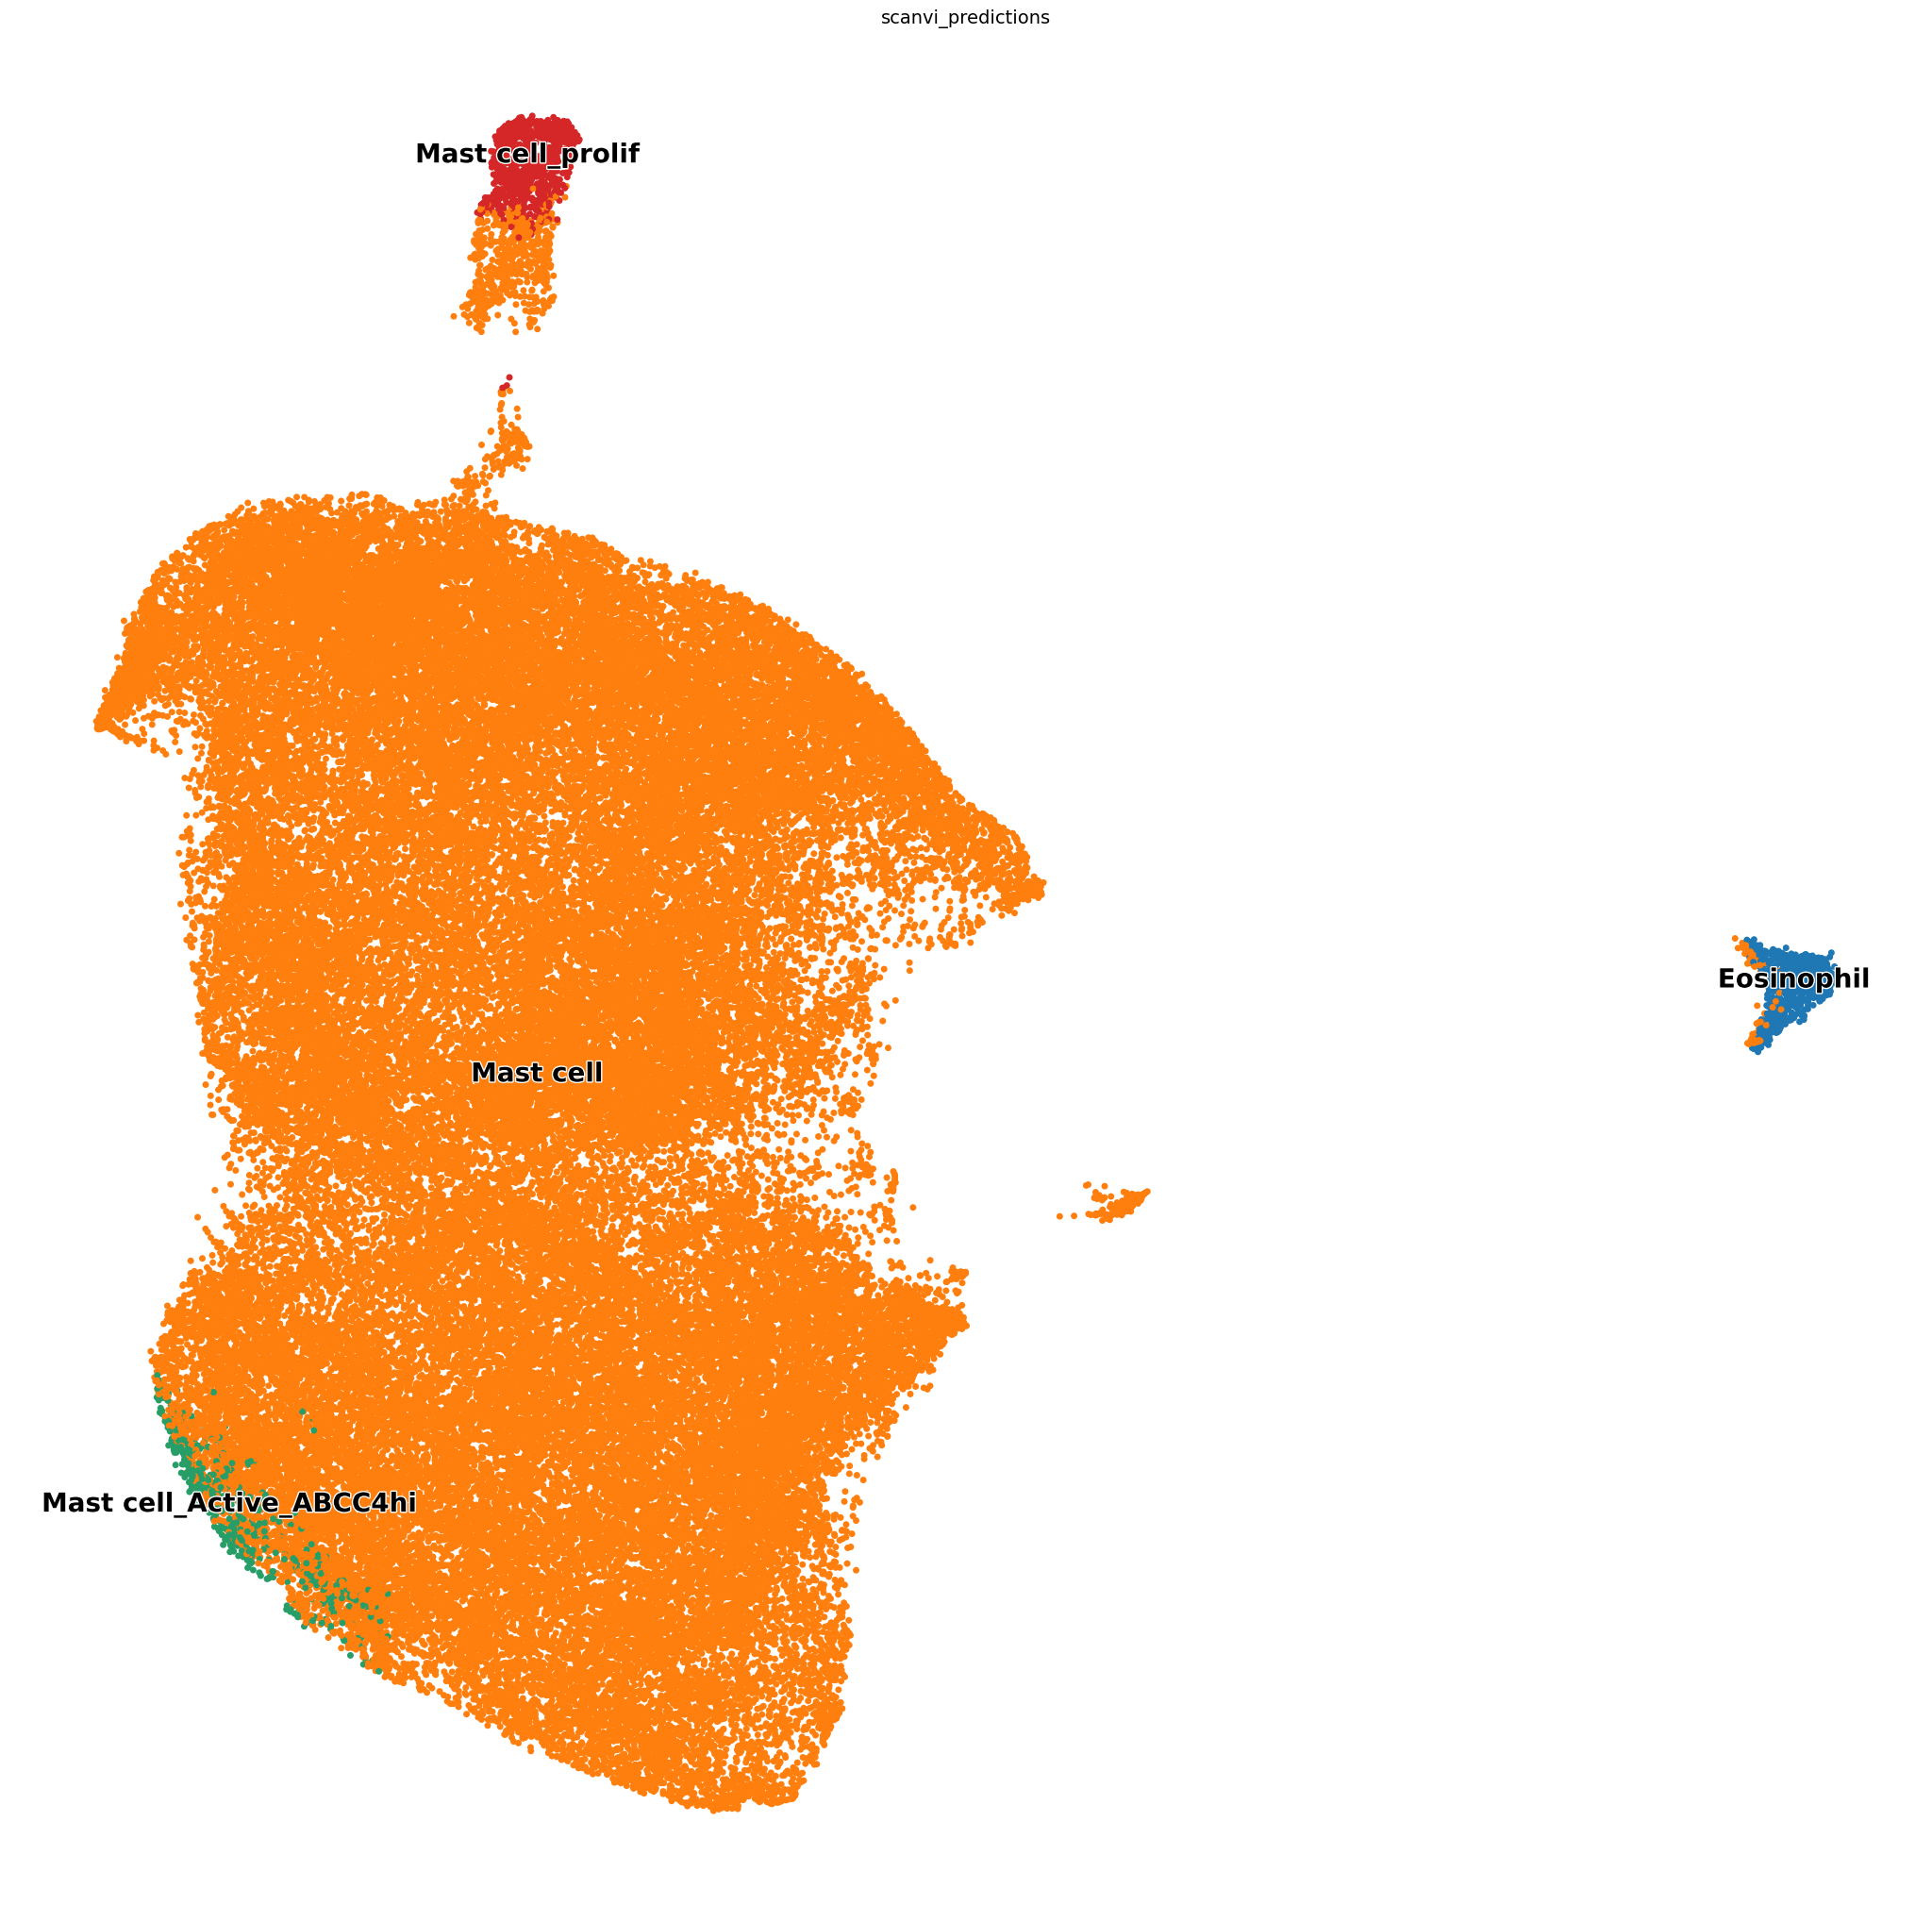

start l.clustering


In [191]:
# sc.pp.neighbors(adata_ii, use_rep = 'X_scanvi', metric = "euclidean", 
#                 n_neighbors=20,key_added="neighbor_20")

# print("neighbours done")
# print("start umap")
# sc.tl.umap(adata_ii, min_dist=0.1, neighbors_key = "neighbor_20" ) 

# sc.pl.umap(
#     adata_ii,
#     color=[
#       'scanvi_predictions',
#     ],
#     legend_loc="on data",
#     s=100, 
#     legend_fontoutline=2,
#     legend_fontsize=20,
#     show=True,
# )
# print("start l.clustering")
# sc.tl.leiden(adata_ii, resolution=1, key_added='leiden_res1', neighbors_key="neighbor_20")


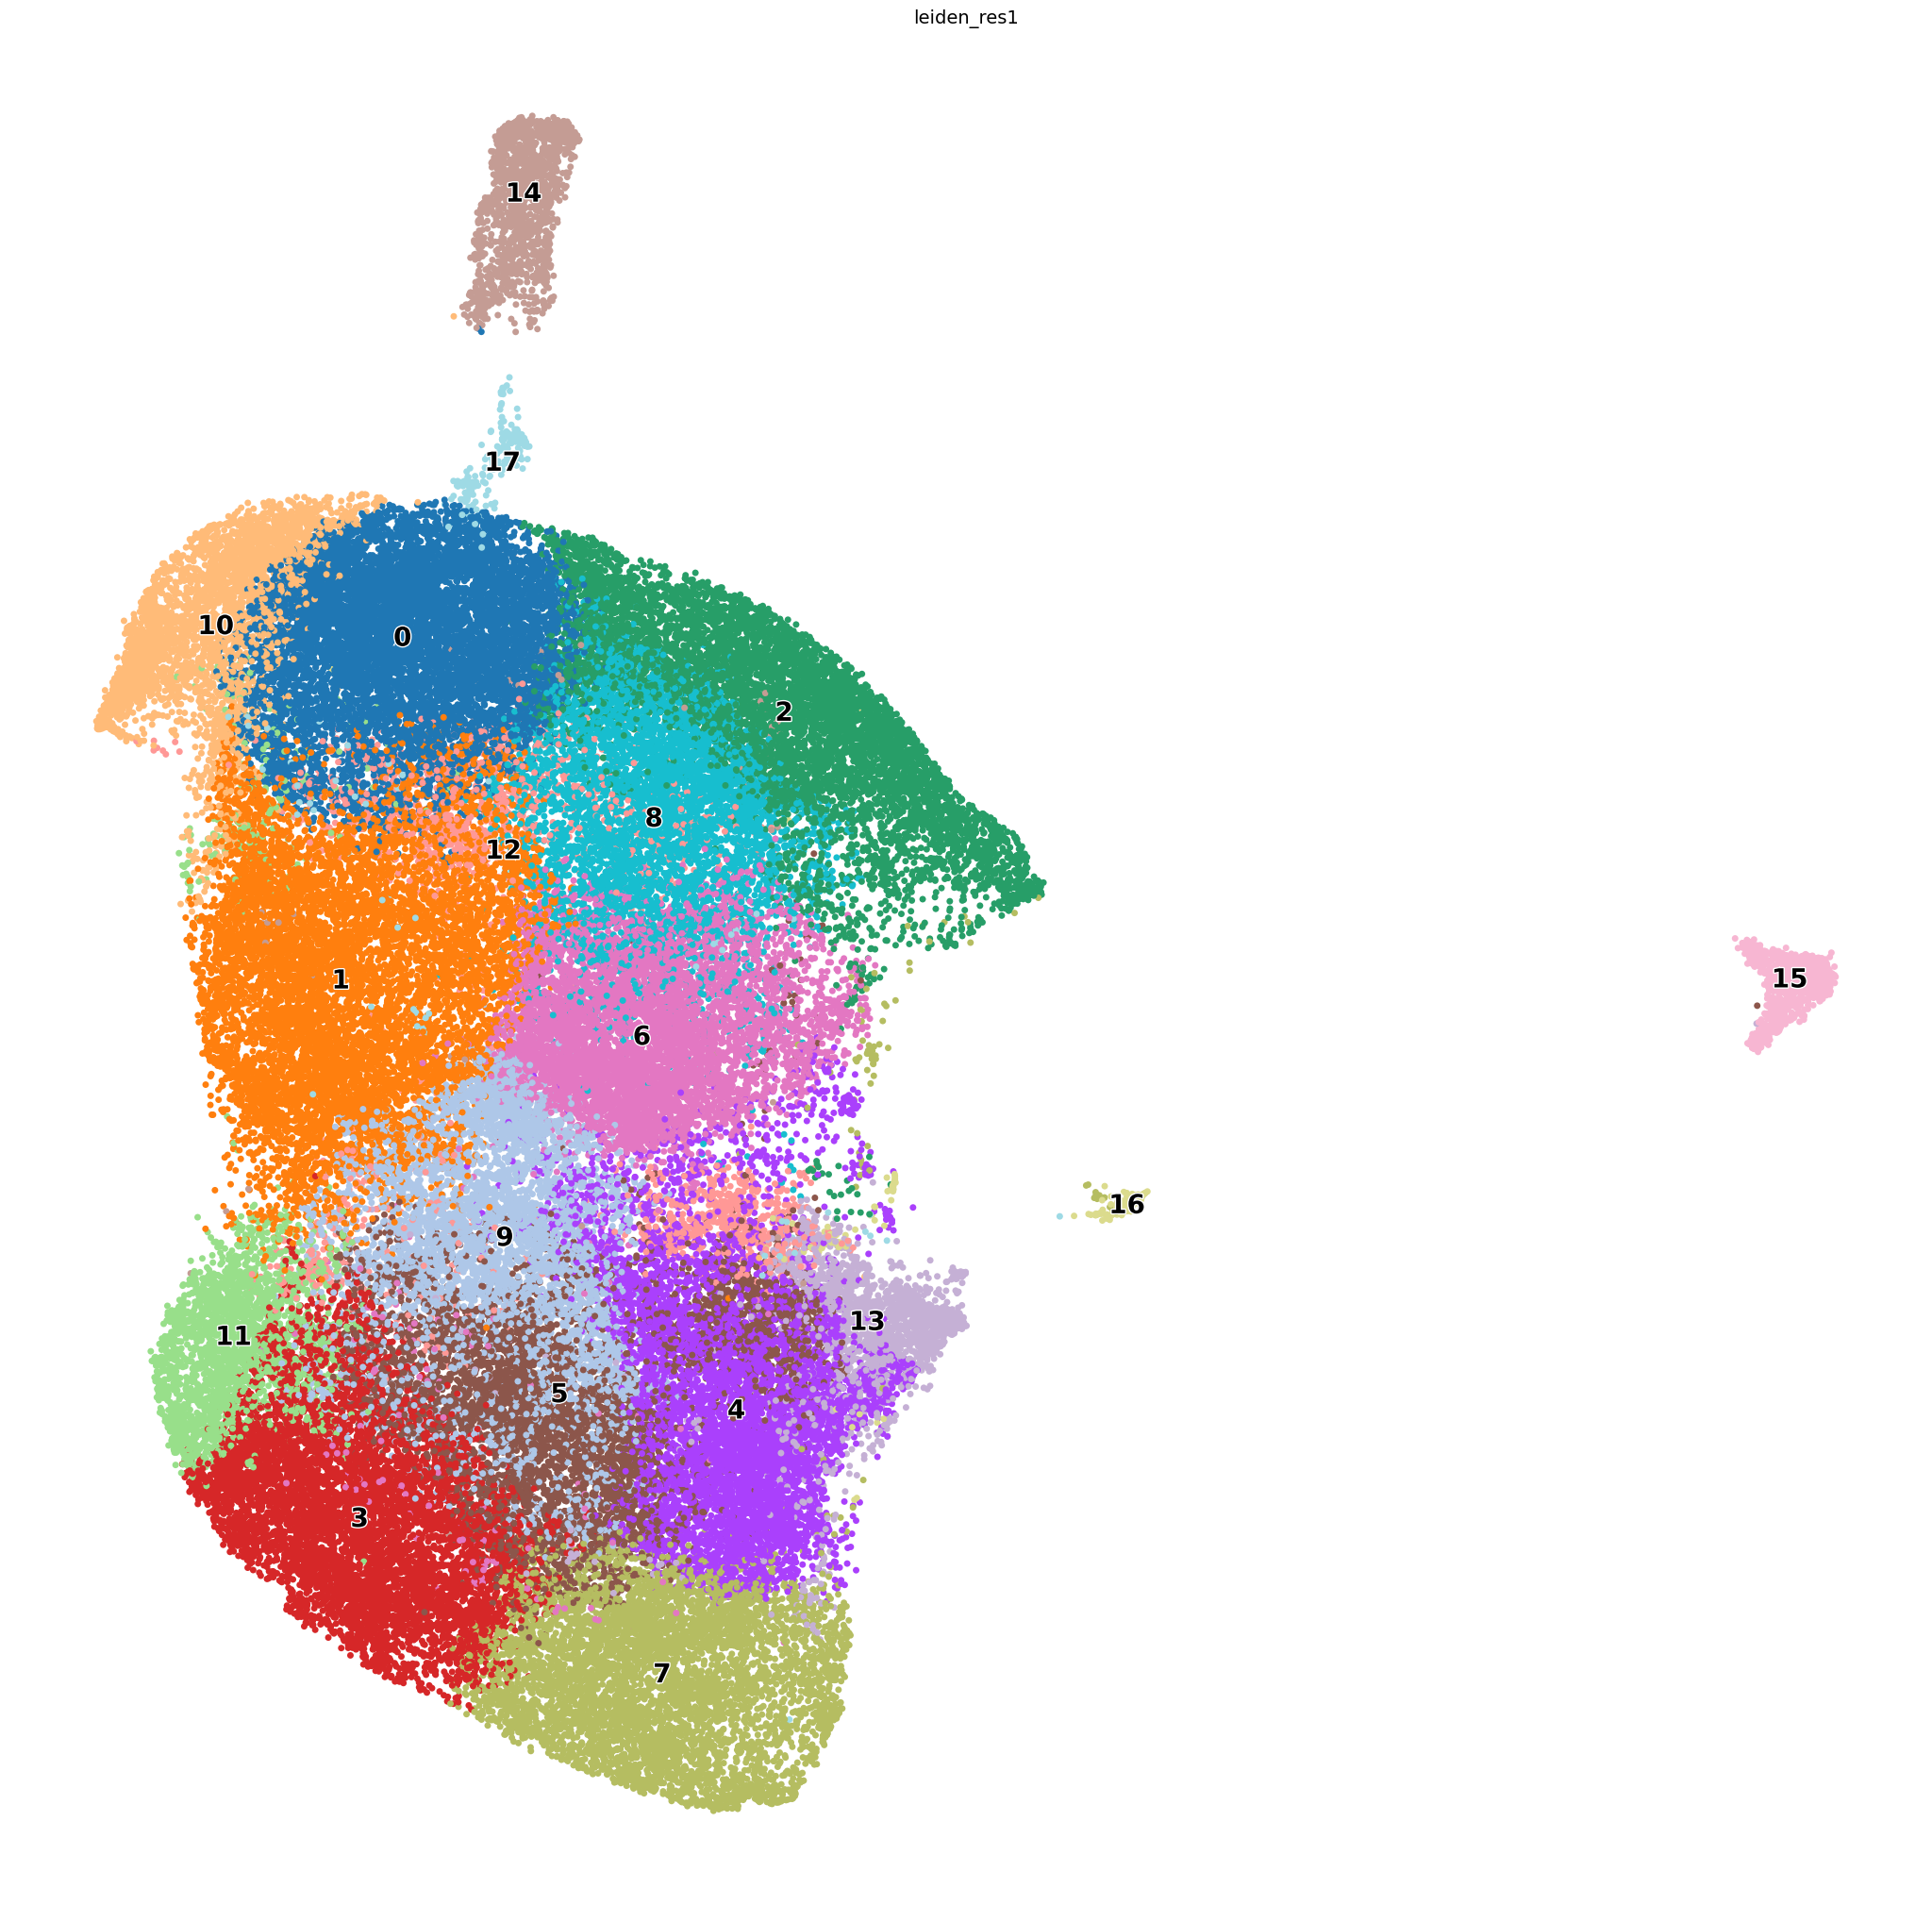

In [192]:
sc.pl.umap(
    adata_ii,
    color=[
      'leiden_res1',
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,
    show=True,
)

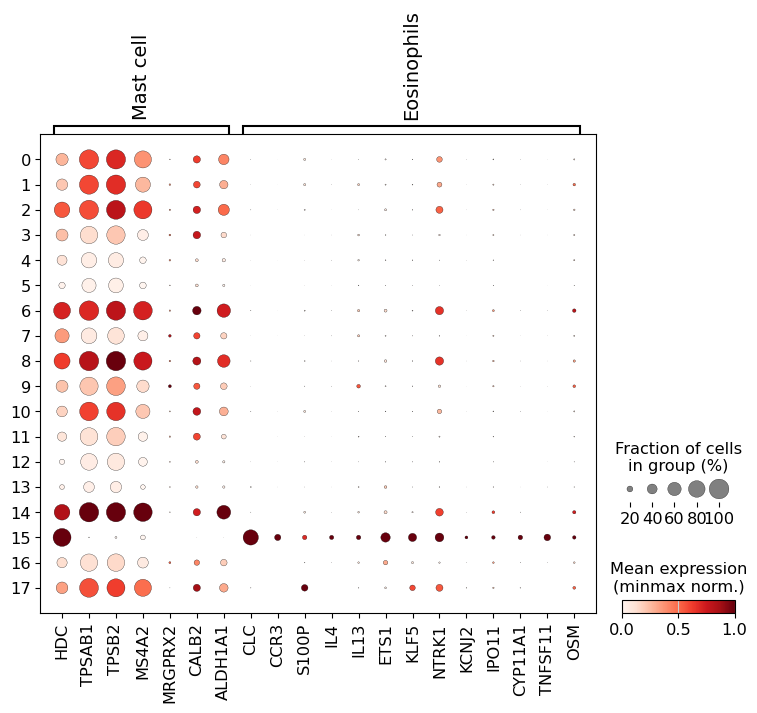

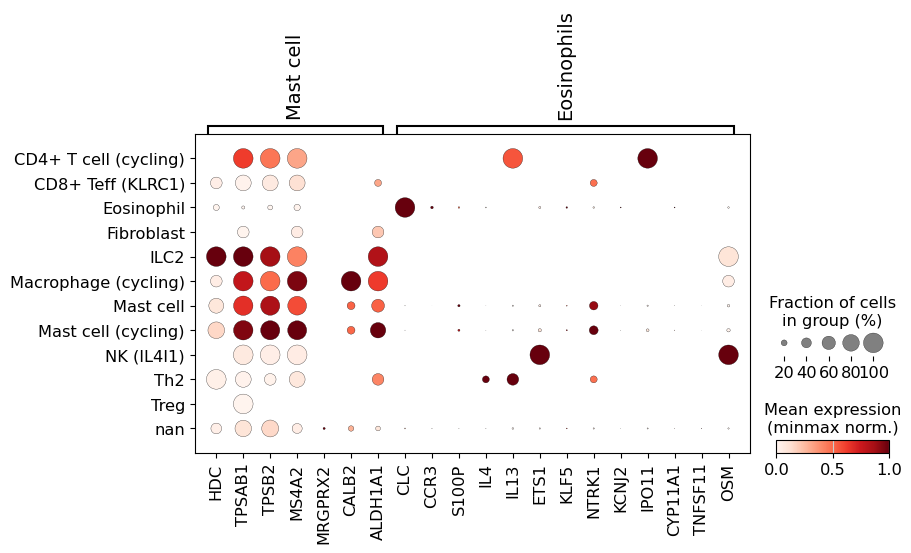

In [193]:
MARKERS = {"Mast cell": [#"HPGDS", "KIT", "HPGD",
                    "HDC", #"GATA2",   
                    "TPSAB1", "TPSB2", "MS4A2","MRGPRX2",
                              "CALB2", "ALDH1A1" #"CAVIN2", "HEY1"
                ],
            "Eosinophils": [ "CLC", "CCR3",#"CCL23",    #"PTGDR2", "P2RY1", 
                            "S100P",
                             "IL4",
    "IL13",
    "ETS1",
    "KLF5",
    "NTRK1",
    "KCNJ2",
    "IPO11",
    "CYP11A1",
    "TNFSF11",
    "OSM"
                           ],}
    
sc.pl.dotplot(
    adata_ii,
    MARKERS,
    groupby="leiden_res1",
    standard_scale="var",
    dendrogram=False,
    vmax=1,
                               colorbar_title="Mean expression\n(minmax norm.)",
    #categories_order = ["Merkel cell", "ILC1", "ILC3", "ILC2"],
                                  #  save="misc_scrna.pdf"

) 
sc.pl.dotplot(
    adata_ii,
    MARKERS,
    groupby="cell_type_anno",
    standard_scale="var",
    dendrogram=False,
    vmax=1,
                               colorbar_title="Mean expression\n(minmax norm.)",
    #categories_order = ["Merkel cell", "ILC1", "ILC3", "ILC2"],
                                  #  save="misc_scrna.pdf"

) 


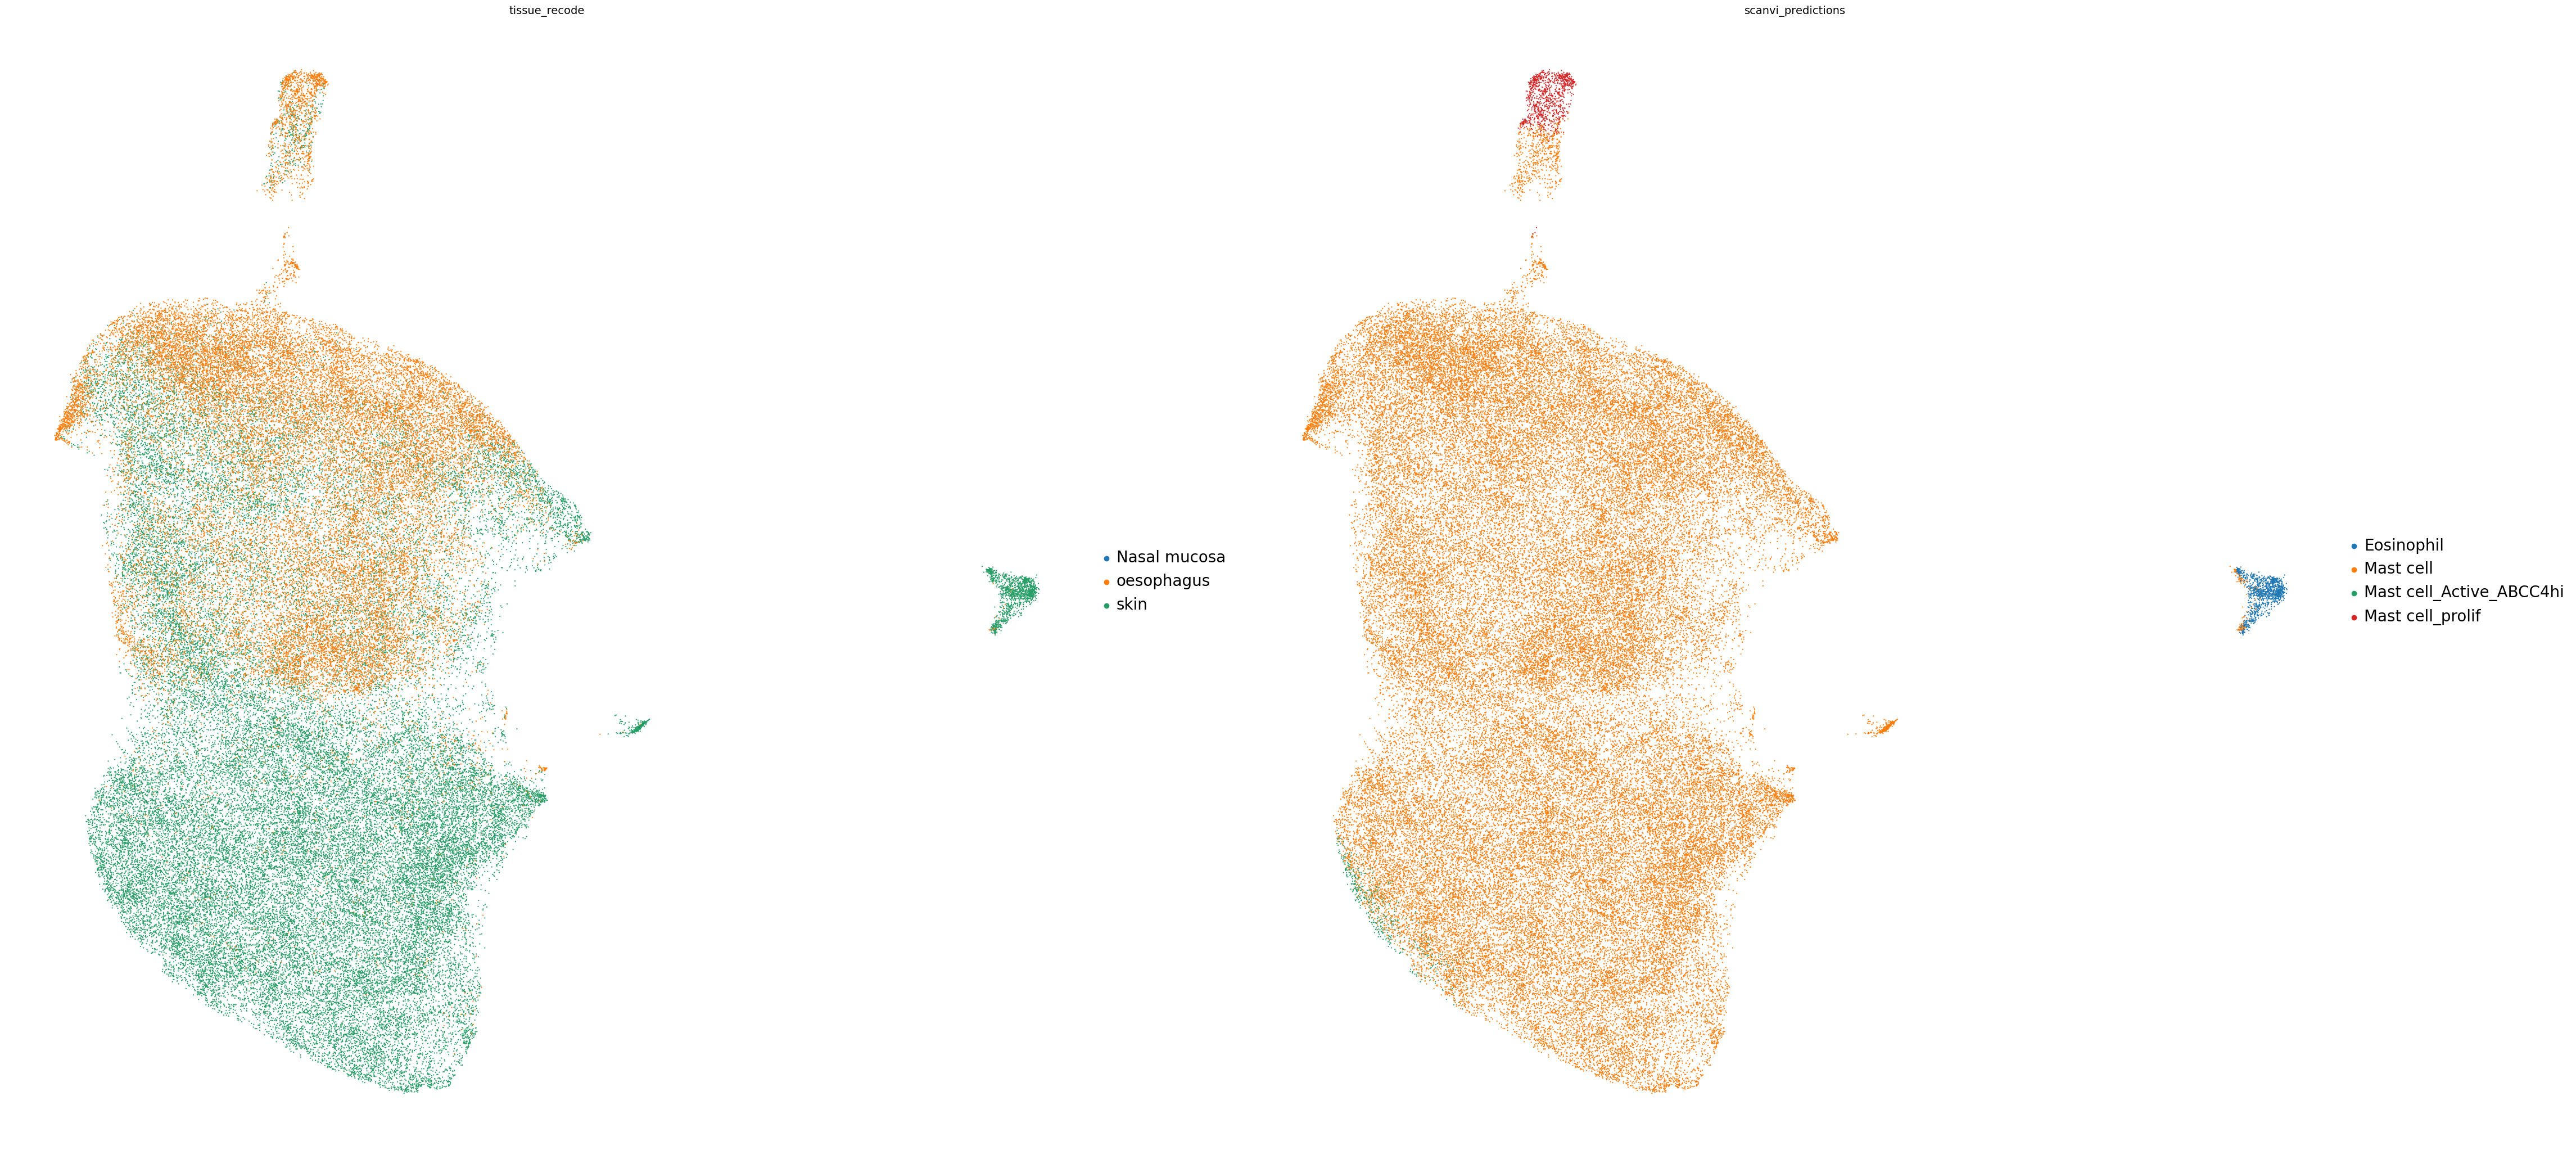

In [194]:
import numpy as np

adata_ii.obs["tissue_recode"] = np.where(
    adata_ii.obs["Patient_status"] == "eoe",
    "oesophagus",
    np.where(
        adata_ii.obs["tissue"] == "Nasal mucosa",
        "Nasal mucosa",
        "skin"
    )
)

sc.pl.umap(
    adata_ii,
    color=[
      'tissue_recode',"scanvi_predictions"
    ],
    #legend_loc="on data",
    s=10, 
    legend_fontoutline=2,
    legend_fontsize=20,
    show=True,
)
 

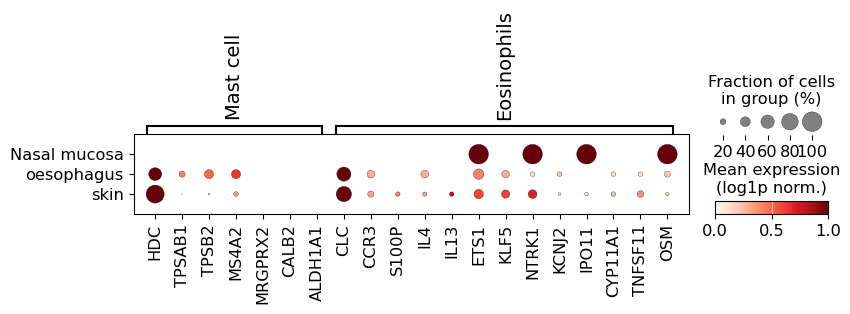

In [195]:
sc.pl.dotplot(
    adata_ii[adata_ii.obs["leiden_res1"]=="15"],
    MARKERS,
    groupby="tissue_recode",
   # standard_scale="var",
    dendrogram=False,
    vmax=1,
                               colorbar_title="Mean expression\n(log1p norm.)",
    #categories_order = ["Merkel cell", "ILC1", "ILC3", "ILC2"],
                                  #  save="misc_scrna.pdf"

) 

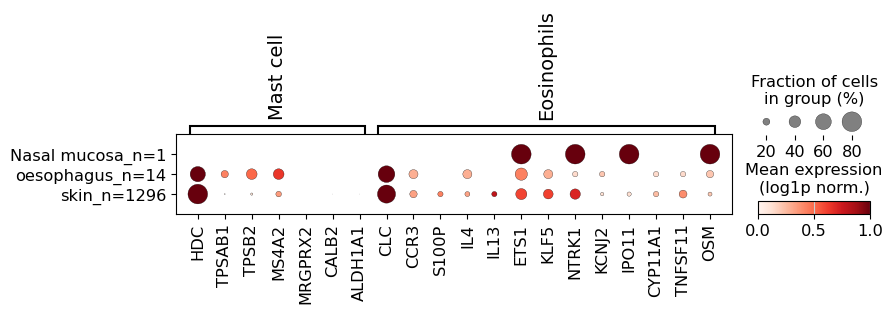

In [196]:
# Subset once, not inside the plotting call
adata_sub = adata_ii[adata_ii.obs["leiden_res1"] == "15"].copy()

# Compute counts per tissue
counts = adata_sub.obs["tissue_recode"].value_counts()

# Build label mapping: tissue → tissue_n=XXX
label_map = {
    k: f"{k}_n={v}"
    for k, v in counts.items()
}

# Create relabeled column
adata_sub.obs["tissue_recode_n"] = (
    adata_sub.obs["tissue_recode"]
    .map(label_map)
    .astype("category")
)

# Plot
sc.pl.dotplot(
    adata_sub,
    MARKERS,
    groupby="tissue_recode_n",
    dendrogram=False,
    vmax=1,
    colorbar_title="Mean expression\n(log1p norm.)",
    dot_max=0.8
)

In [197]:
adata_ii[adata_ii.obs["leiden_res1"]=="15"].obs.Patient_status.value_counts()

Patient_status
Bullous pemphigoid               1232
AD                                 21
eoe                                14
Healthy                            10
BCC                                 6
HS                                  5
SCC                                 4
Psoriasis                           3
nan                                 3
AA                                  2
Sarcoidosis                         2
PWH27D7                             2
Non-keloid scar                     1
Lichen planus                       1
Keloid                              1
Dupuytren                           1
Lyme_disease/Erythema migrans       1
Prurigo                             1
eCRSwNP                             1
Name: count, dtype: int64

In [198]:
adata_ii[adata_ii.obs["Patient_status"]=="nan"].obs.dataset_id.value_counts()

dataset_id
gudjonsson_regional    5459
Name: count, dtype: int64

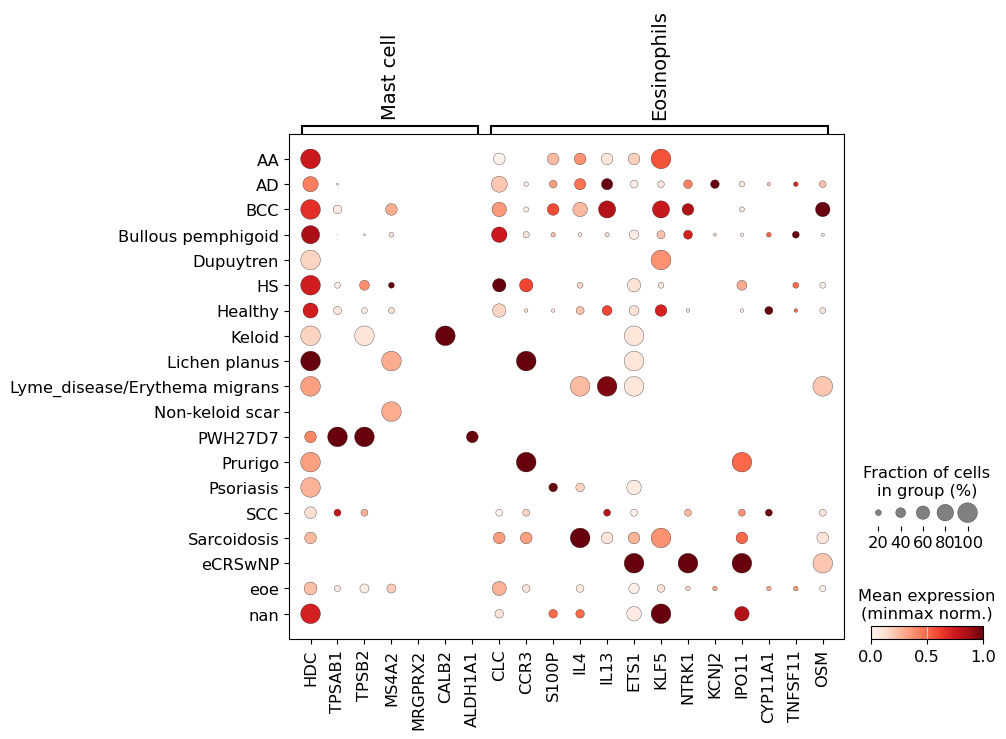

In [199]:
sc.pl.dotplot(
    adata_ii[adata_ii.obs["leiden_res1"]=="15"],
    MARKERS,
    groupby="Patient_status",
    standard_scale="var",
    dendrogram=False,
    vmax=1,
                               colorbar_title="Mean expression\n(minmax norm.)",
    #categories_order = ["Merkel cell", "ILC1", "ILC3", "ILC2"],
                                  #  save="misc_scrna.pdf"

) 

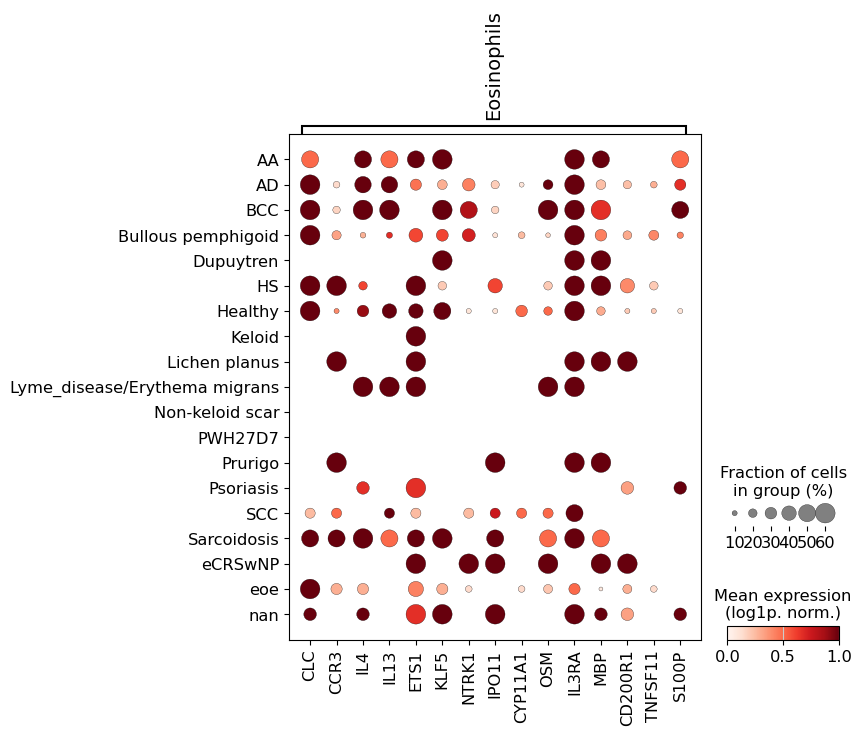

In [200]:
MARKERS = {  "Eosinophils": [ "CLC", "CCR3",#"CCL23",    #"PTGDR2", "P2RY1", 
                         
                             "IL4",
    "IL13",
    "ETS1",
    "KLF5",
    "NTRK1",
 
    "IPO11",
    "CYP11A1",

    "OSM", 
   "IL3RA","MBP","CD200R1",    "TNFSF11",   "S100P",
                            
                           ]}

sc.pl.dotplot(
    adata_ii[adata_ii.obs["leiden_res1"]=="15"],
    MARKERS,
    groupby="Patient_status",
    #standard_scale="var",
    dendrogram=False,
    vmax=1,
    dot_max=.6,
                               colorbar_title="Mean expression\n(log1p. norm.)",
    #categories_order = ["Merkel cell", "ILC1", "ILC3", "ILC2"],
                                  #  save="misc_scrna.pdf"

) 

In [201]:
# sc.pp.normalize_total(adata_ii, target_sum=1e4)
# sc.pp.log1p(adata_ii)

In [202]:
# PATH='/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_output//SpatialSkinAtlasMapping_scanviSpatialSkinAtlasMapping_SYSTEMIC_V3_HVGNUMBER5955__MAXEPOCHS10__BATCHKEYsample_id/adata_mast_eos_normalized_sysemic.h5ad'
# adata_ii.write(PATH)


In [203]:
RENAME = {'nan': "Healthy",
         "eoe": "Eosinophilic oesophagitis",
          "eCRSwNP":"Eosinophilic chronic rhinosinusitis"
         }
adata_ii.obs["Patient_status"]=adata_ii.obs["Patient_status"].map(RENAME).fillna(adata_ii.obs["Patient_status"])

In [204]:
adata_sub = adata_ii[adata_ii.obs["leiden_res1"] == "15"].copy()
list(adata_sub.obs["Patient_status"].unique())
adata_sub=adata_sub[adata_sub.obs["Patient_status"]!="Psoriasis"]
adata_sub=adata_sub[adata_sub.obs["Patient_status"]!="PWH27D7"]


AttributeError: 'AnnData' object has no attribute 'value_counts'

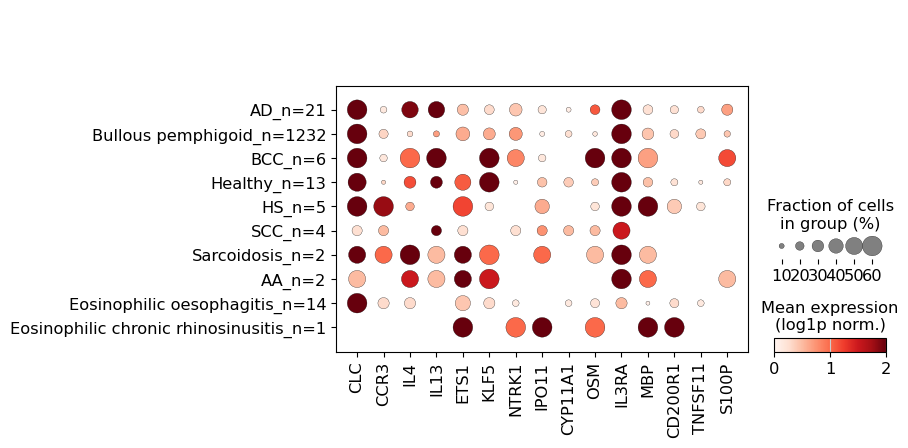

In [207]:
MARKERS =   [ "CLC", "CCR3",#"CCL23",    #"PTGDR2", "P2RY1", 
                         
                             "IL4",
    "IL13",
    "ETS1",
    "KLF5",
    "NTRK1",
 
    "IPO11",
    "CYP11A1",

    "OSM", 
   "IL3RA","MBP","CD200R1",    "TNFSF11",   "S100P",
                            
                           ]
# Count cells per patient status
counts = adata_sub.obs["Patient_status"].value_counts()

# Keep statuses with >=2 counts OR "eCRSwNP"
keep = counts[counts >= 2].index.union(["Eosinophilic chronic rhinosinusitis"])
adata_sub = adata_sub[adata_sub.obs["Patient_status"].isin(keep)].copy()

# Recompute counts after filtering
counts = adata_sub.obs["Patient_status"].value_counts()

# Build mapping: status → status_n=XXX
label_map = {
    k: f"{k}_n={v}"
    for k, v in counts.items()
}

ORDER=[
     'AD_n=21',
     'Bullous pemphigoid_n=1232',
     'BCC_n=6',
    'Healthy_n=13',
     'HS_n=5',
 'SCC_n=4',
 'Sarcoidosis_n=2',
 'AA_n=2',
 'Eosinophilic oesophagitis_n=14',
 'Eosinophilic chronic rhinosinusitis_n=1']

# Create relabeled grouping column
adata_sub.obs["Patient_status_n"] = (
    adata_sub.obs["Patient_status"]
    .map(label_map)
    .astype("category")
)

# Plot
sc.pl.dotplot(
    adata_sub,
    MARKERS,
    groupby="Patient_status_n",
    #standard_scale="var",
    dendrogram=False,
    vmax=2,
    dot_max=.6,
    colorbar_title="Mean expression\n(log1p norm.)",
        categories_order=ORDER,
    save="eosinophil_crosstissue.pdf"
)

In [208]:
list(adata_sub.obs["Patient_status_n"].unique())

['Healthy_n=13',
 'SCC_n=4',
 'AD_n=21',
 'Bullous pemphigoid_n=1232',
 'BCC_n=6',
 'Sarcoidosis_n=2',
 'AA_n=2',
 'HS_n=5',
 'Eosinophilic oesophagitis_n=14',
 'Eosinophilic chronic rhinosinusitis_n=1']

neighbours done
start umap


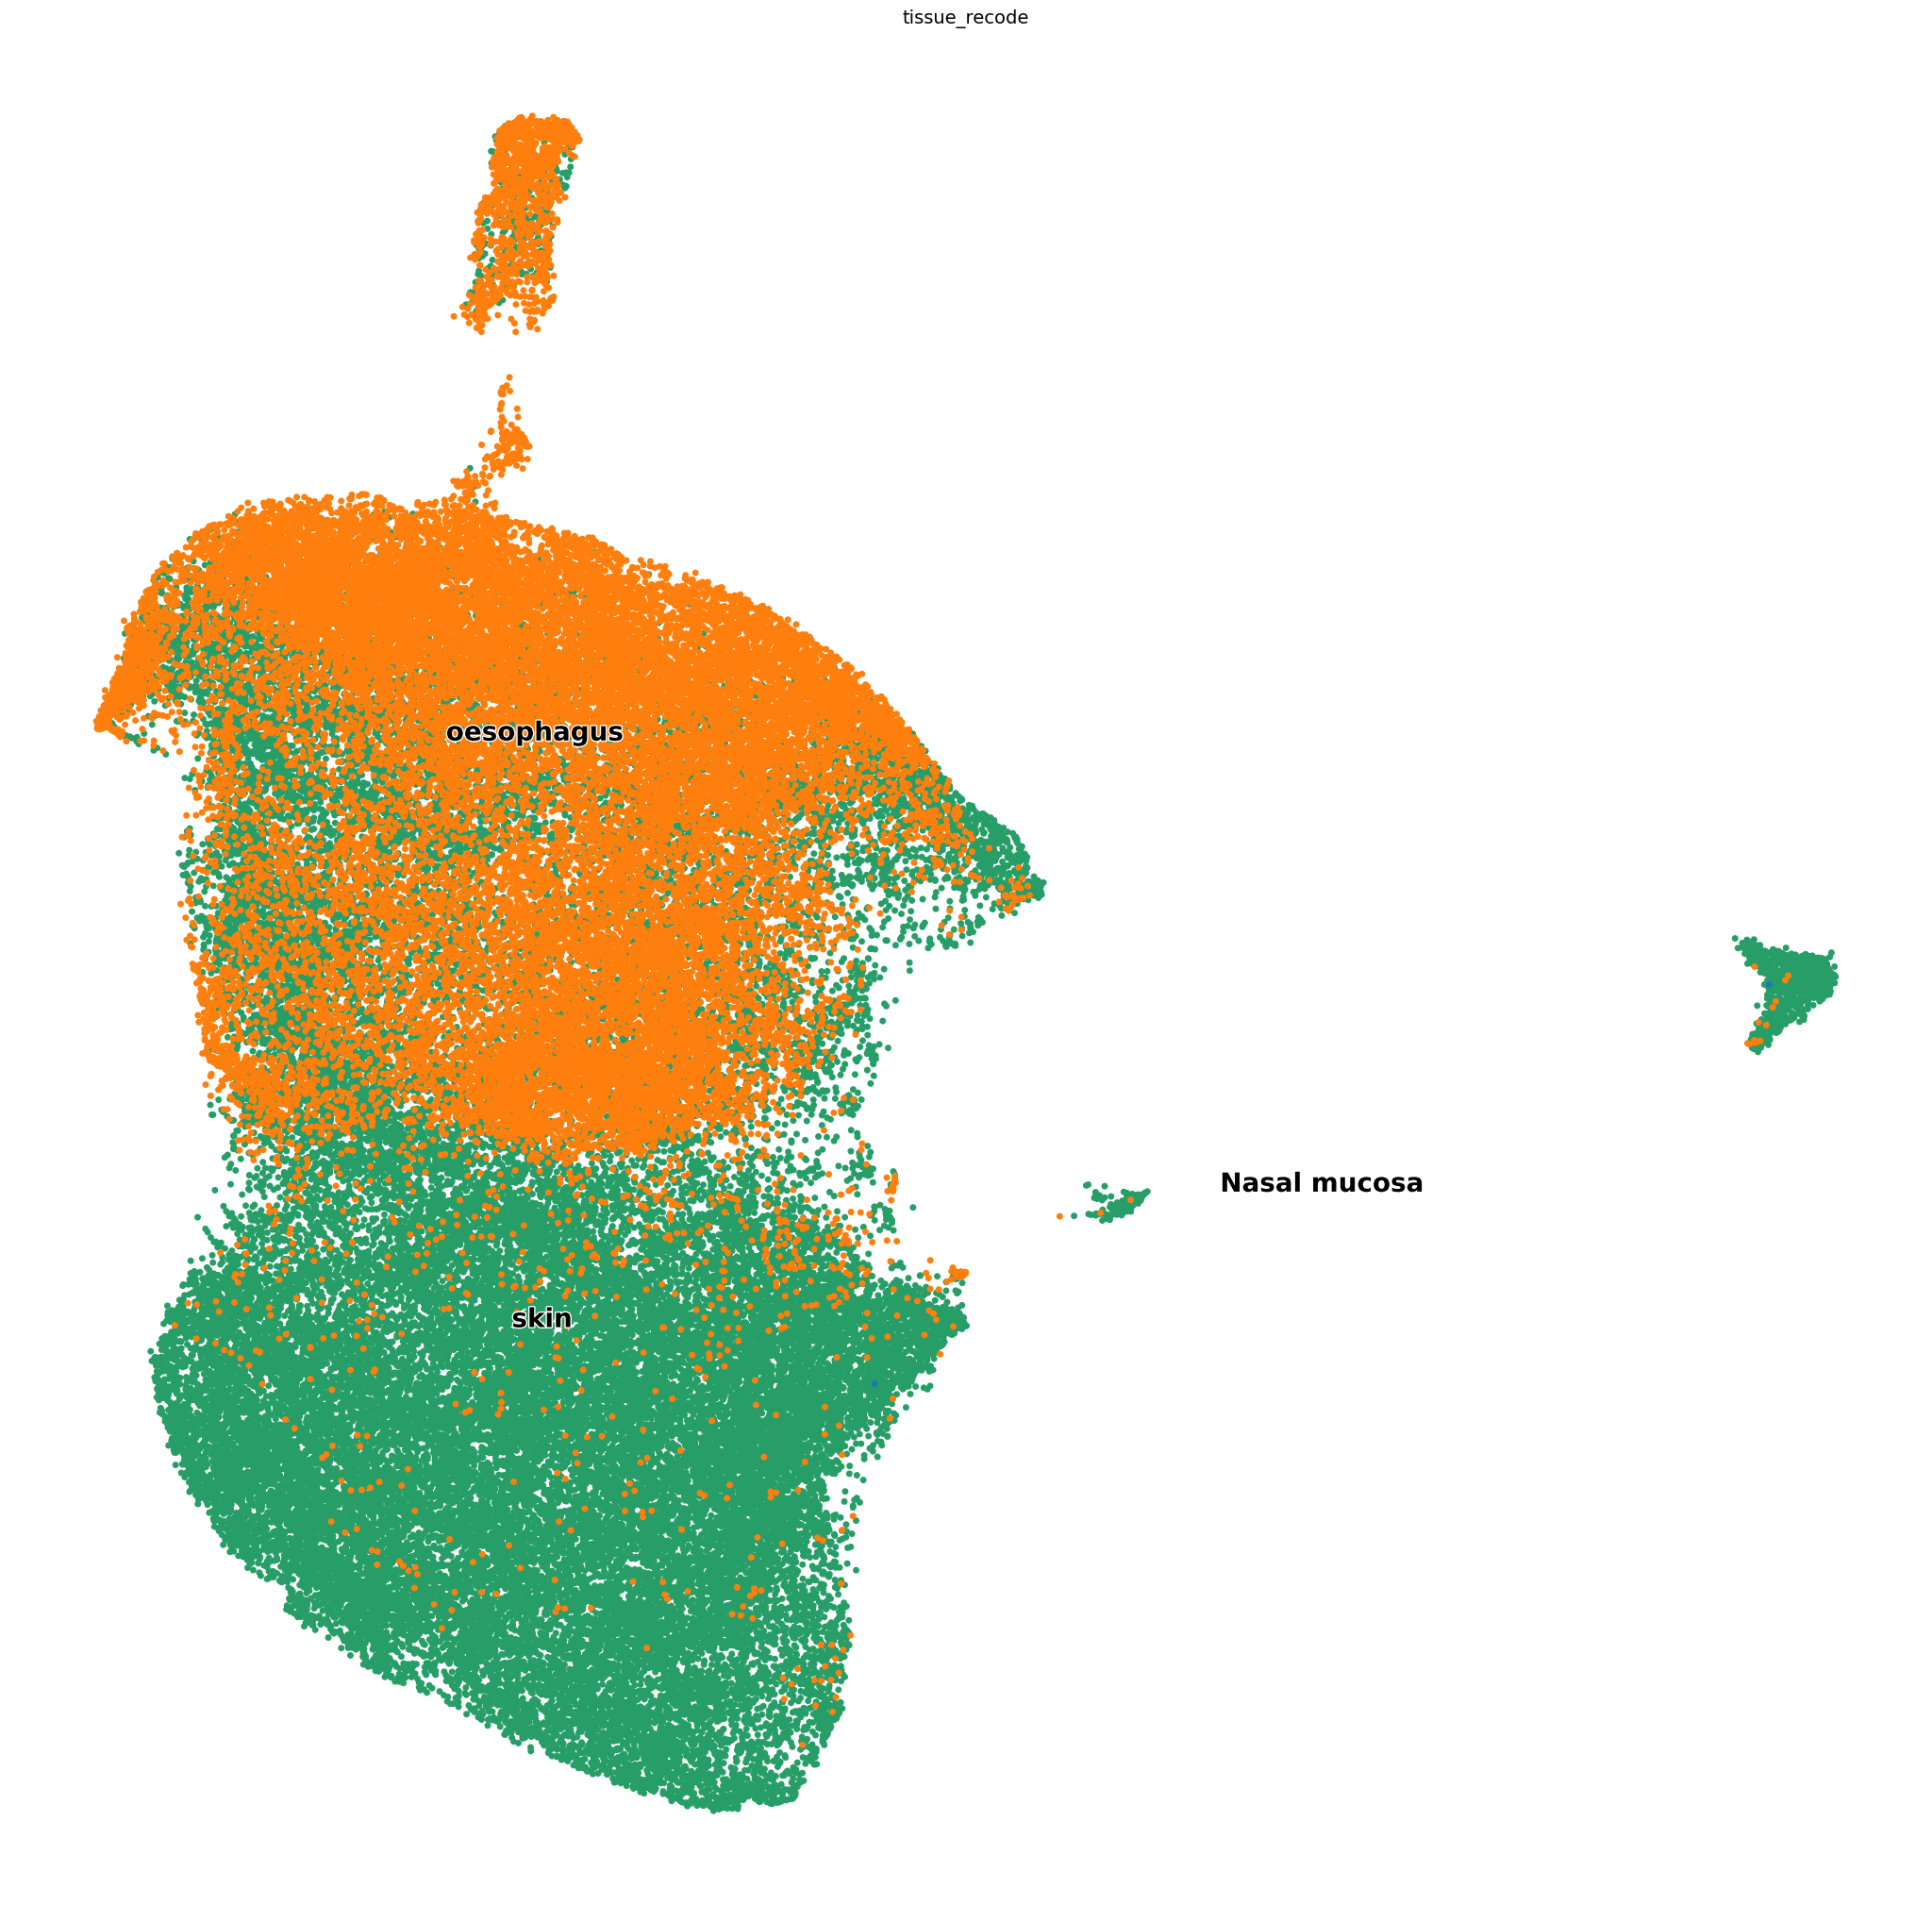

In [209]:
sc.pp.neighbors(adata_sub, use_rep = 'X_scanvi', metric = "euclidean", 
                n_neighbors=20,key_added="neighbor_20")

print("neighbours done")
print("start umap")
sc.tl.umap(adata_sub, min_dist=0.1, neighbors_key = "neighbor_20" ) 

sc.pl.umap(
    adata_ii,
    color=[
      'tissue_recode',
    ],
    legend_loc="on data",
    s=100, 
    legend_fontoutline=2,
    legend_fontsize=20,
    show=True,
)
#print("start l.clustering")
#sc.tl.leiden(adata_ii, resolution=1, key_added='leiden_res1', neighbors_key="neighbor_20")


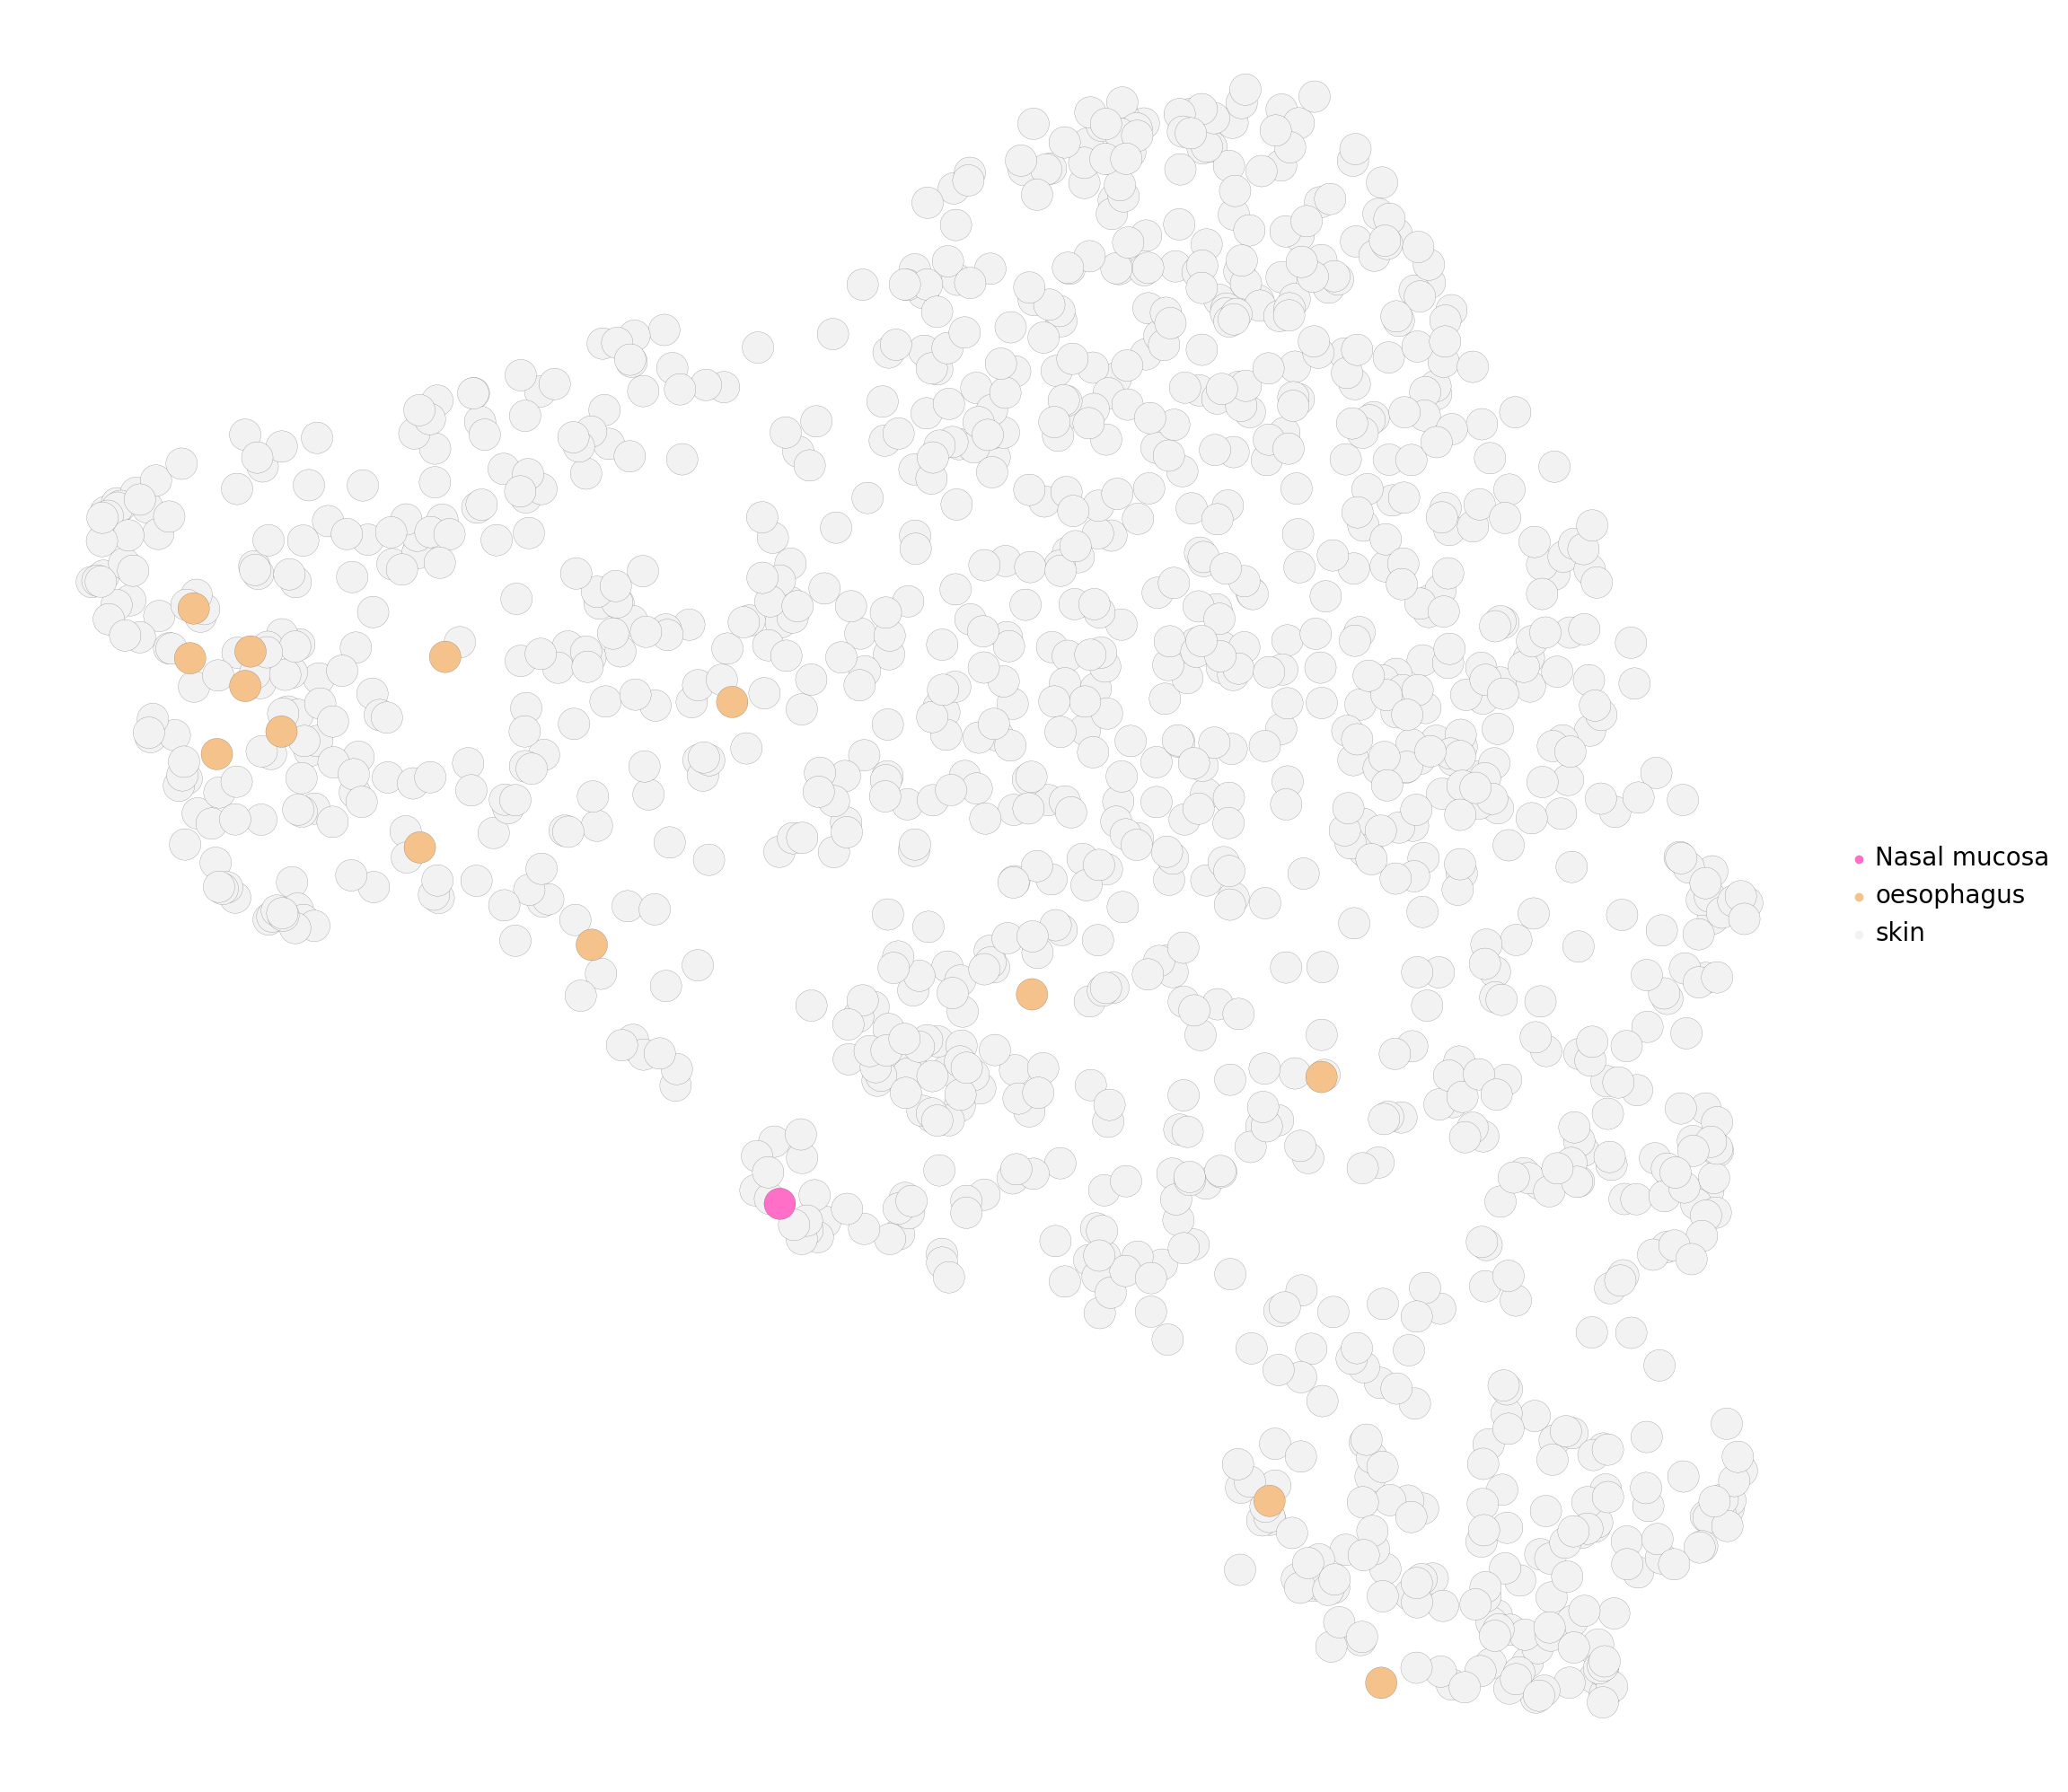

In [210]:
tissue_colors = {
    "skin": "#F2F2F2",           # very light grey
    "oesophagus": "#F6C28B",     # pastel orange
    "Nasal mucosa": "#FF6EC7",   # pastel pink
}
sc.pl.umap(
    adata_sub,
    color=[
      'tissue_recode',
    ],
    #legend_loc="on data",
    s=2550, 
    legend_fontoutline=2,
    legend_fontsize=20,
    show=True,
    palette=tissue_colors,
    linewidth=0.1,
    edgecolor='black',
    title='',
            save="eos_tissue_umap.pdf"

)
 

In [214]:

# CATEGORY="leiden_res1"
# import pandas as pd
# sc.tl.rank_genes_groups(adata_ii, CATEGORY, method='wilcoxon', key_added="de_leiden");
# df22 = pd.DataFrame(adata_ii.uns['de_leiden']['names'])
# for i,x in enumerate(df22.columns):
#     print(i, x)
# select_population = list(df22.columns)[-1
                                       
                                       
#                                       ]  # JAW
# print(select_population)
# genes0 = df22[select_population][:50]
# genes1 = df22[select_population][50:100]
# genes2 = df22[select_population][100:150]
# genes3 = df22[select_population][150:200]
# genes4 = df22[select_population][200:250]
# genes5 = df22[select_population][250:300]


# sc.pl.dotplot(
#     adata_ii,
#     genes0,
#     groupby=CATEGORY,
#     standard_scale="var",
#     dendrogram=False, 
# )
# sc.pl.dotplot(
#     adata_ii,
#     genes1,
#     groupby=CATEGORY,
#    standard_scale="var",
#     dendrogram=False, 
# ) 
 

In [212]:
# select_population = list(df22.columns)[-2
                                       
                                       
#                                       ]  # JAW
# print(select_population)
# genes0 = df22[select_population][:50]
# genes1 = df22[select_population][50:100]
# genes2 = df22[select_population][100:150]
# genes3 = df22[select_population][150:200]
# genes4 = df22[select_population][200:250]
# genes5 = df22[select_population][250:300]


# sc.pl.dotplot(
#     adata_ii,
#     genes0,
#     groupby=CATEGORY,
#     standard_scale="var",
#     dendrogram=False, 
# )
# sc.pl.dotplot(
#     adata_ii,
#     genes1,
#     groupby=CATEGORY,
#    standard_scale="var",
#     dendrogram=False, 
# ) 
 